## Zadania do samodzielnego wykonania

1.

Proszę pobrać zbiór fasion MNIST (torchvision.datasets.FashionMNIST) i zaproponować sieć konwolucyjną do jego klasyfikacji. Dla co najmniej trzech architektur proszę wypisać macierz pomyłek i wykresy funkcji strat podczas uczenia. Proszę spróbować w każdym wypadku podać przynajmniej jeden źle zaklasyfikowany obrazek.

2.

Dla jednej wybranej architektury, proszę porównać czas uczenia sieci na CPU i na GPU, do czego mogą Państwo wykorzystać własną kartę NVidii lub zasoby Colaba. W Runtime->Change Runtime Type musi być zaznaczona opcja "T4 GPU".

3*.

Dla zainteresowanych - proszę doczytać o mechanizmie dropoutu (https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html, https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/) i spróbować zastosować mechanizm dropoutu do stworzonej sieci neuronowej.

# Zadanie 1


Training and testing: CNN1
Epoch 1, Loss: 0.46723561743492764
Epoch 2, Loss: 0.32997592903975487
Epoch 3, Loss: 0.2967777980098338
Epoch 4, Loss: 0.27542120220659894
Epoch 5, Loss: 0.26017469155794776


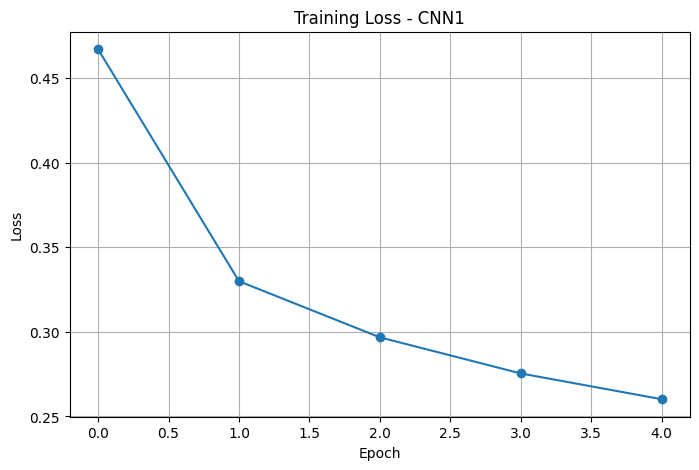

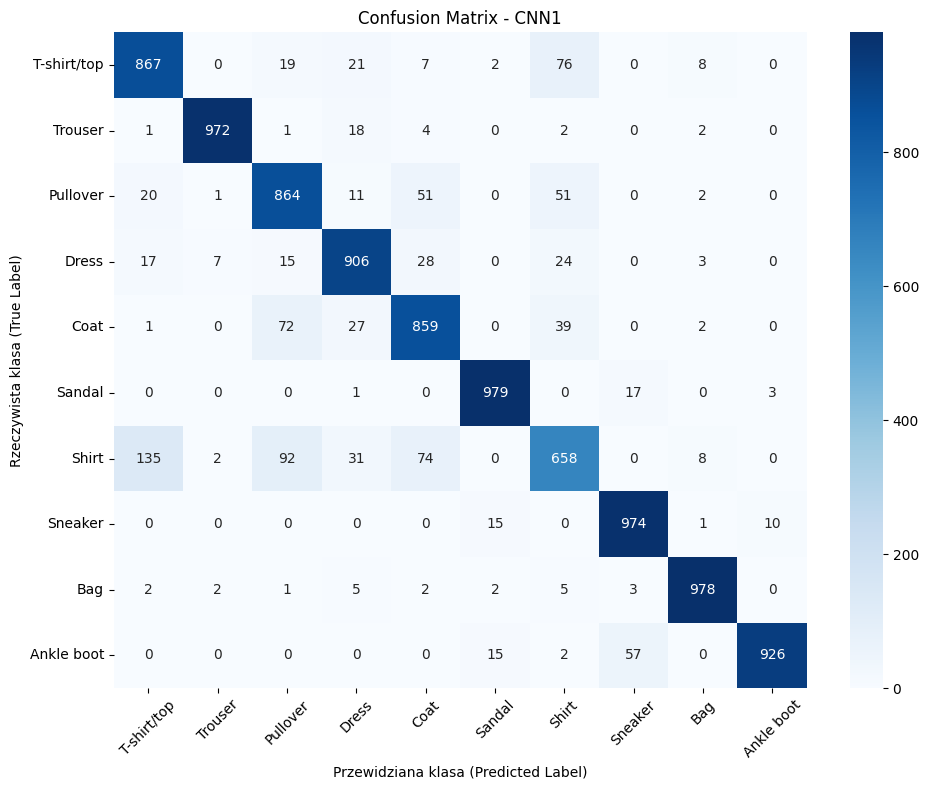

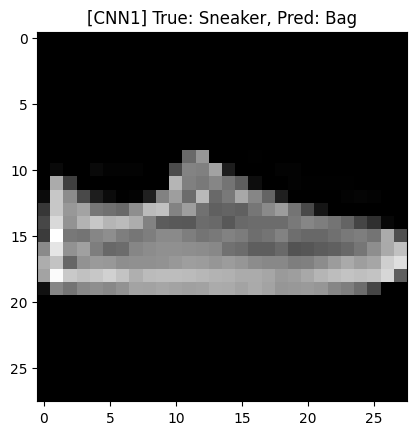


Training and testing: CNN2
Epoch 1, Loss: 0.47184914418819873
Epoch 2, Loss: 0.3136344229949436
Epoch 3, Loss: 0.267089843106613
Epoch 4, Loss: 0.23540449276693595
Epoch 5, Loss: 0.20864560692978185


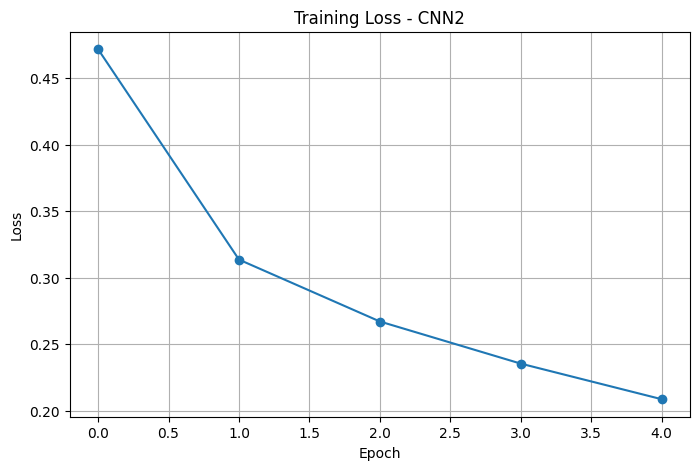

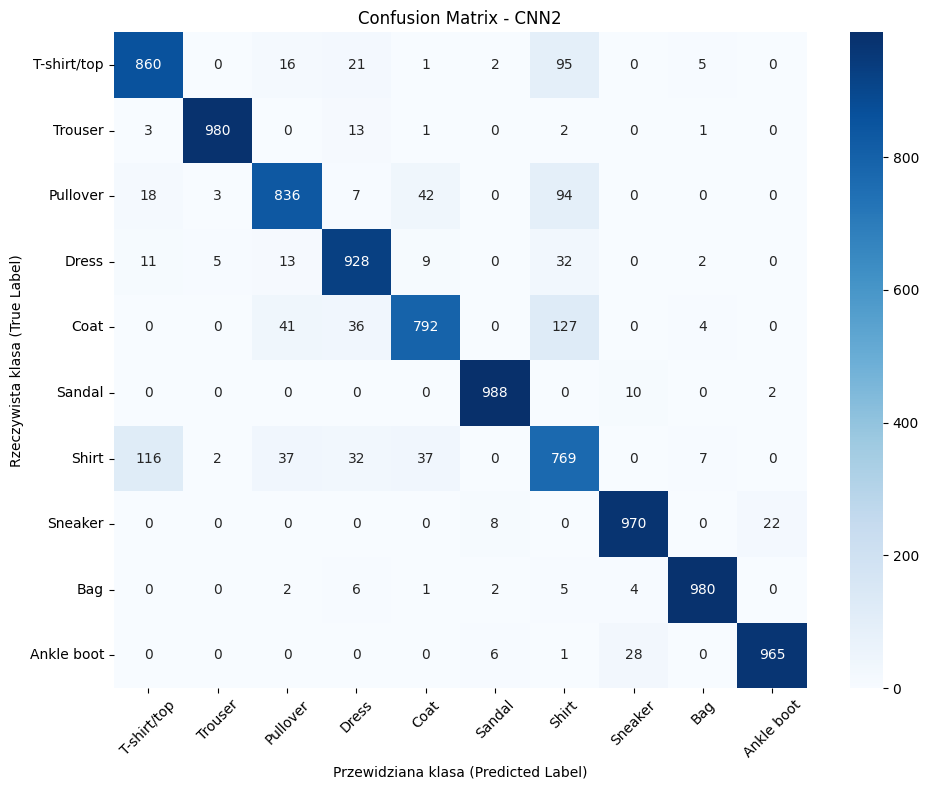

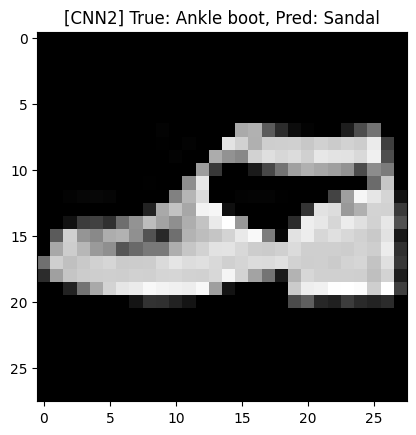


Training and testing: CNN3
Epoch 1, Loss: 0.4529285652360428
Epoch 2, Loss: 0.29445876371758833
Epoch 3, Loss: 0.2440596926194836
Epoch 4, Loss: 0.21181176484091832
Epoch 5, Loss: 0.18488216116182457


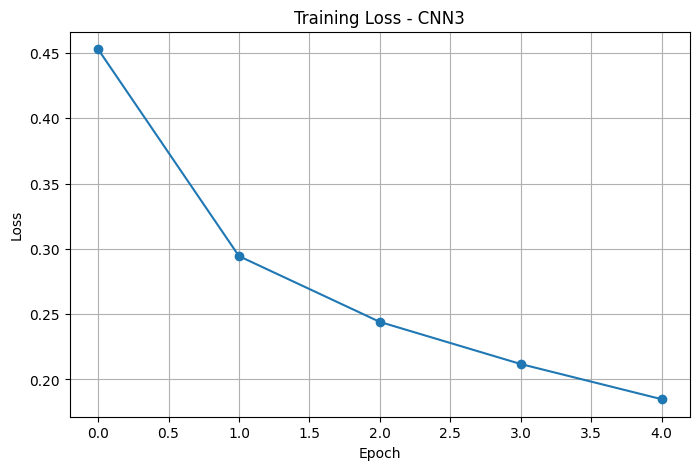

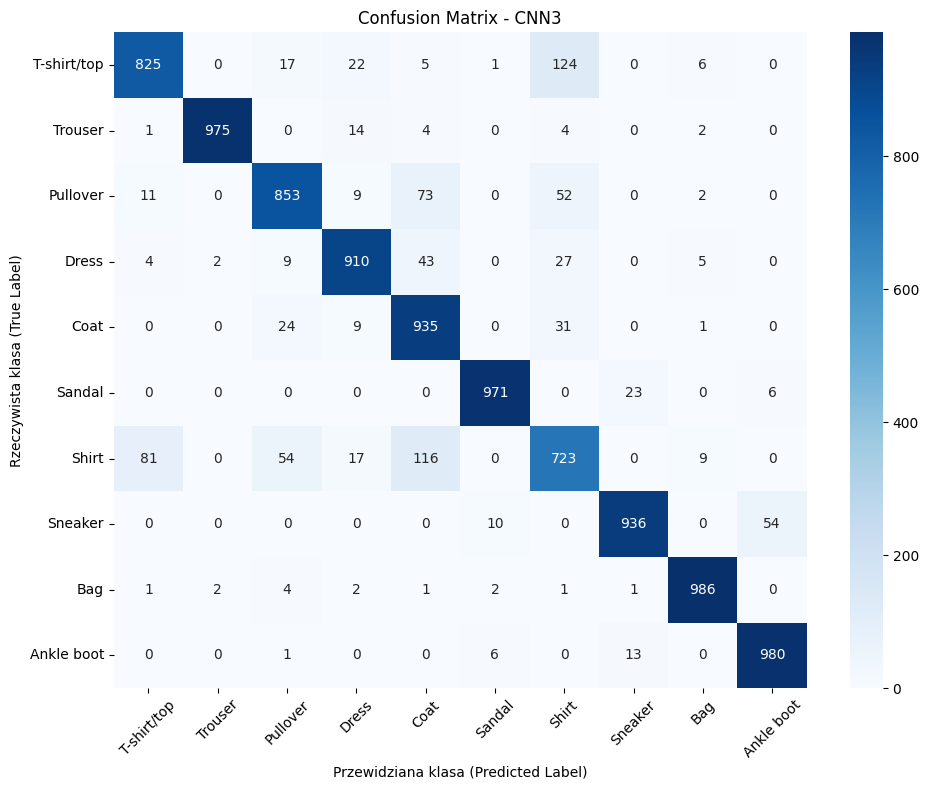

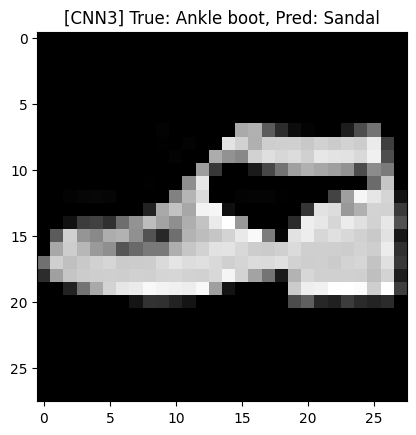

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Import danych
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Architektury sieci
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 13 * 13, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 16 * 13 * 13)
        x = self.fc1(x)
        return x

class CNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64 * 5 * 5, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Traning i ocena
def train_model(model):
    model.train() 
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    losses = []

    for epoch in range(5):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss}")
    return losses

def evaluate(model, model_name=""):
    model.eval() 
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=fashion_classes, 
                yticklabels=fashion_classes)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel('Rzeczywista klasa (True Label)')
    plt.xlabel('Przewidziana klasa (Predicted Label)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return cm, all_preds, all_labels

def show_misclassified(model, model_name=""):
    model.eval() 
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    plt.imshow(images[i].squeeze(), cmap='gray')
                    # Выводим текстовое название класса вместо цифры
                    true_label = fashion_classes[labels[i]]
                    pred_label = fashion_classes[preds[i]]
                    plt.title(f"[{model_name}] True: {true_label}, Pred: {pred_label}")
                    plt.show()
                    return 

# Zadania dla architektur
models = [CNN1(), CNN2(), CNN3()]
model_names = ["CNN1", "CNN2", "CNN3"]

for i, model in enumerate(models):
    print(f"\n{'='*50}")
    print(f"Training and testing: {model_names[i]}")
    print(f"{'='*50}")
    
    losses = train_model(model)
    
    plt.figure(figsize=(8, 5))
    plt.plot(losses, marker='o', linestyle='-')
    plt.title(f"Training Loss - {model_names[i]}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
    
    cm, preds, labels = evaluate(model, model_names[i])
    show_misclassified(model, model_names[i])

# Zadanie 2


Dla jednej wybranej architektury, proszę porównać czas uczenia sieci na CPU i na GPU, do czego mogą Państwo wykorzystać własną kartę NVidii lub zasoby Colaba. W Runtime->Change Runtime Type musi być zaznaczona opcja "T4 GPU".

In [6]:
#Check if GPU is available
import torch
print(torch.cuda.is_available())  # should be True

True


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
#Moving model to device
model = CNN2().to(device)

In [9]:
#Moving data to device
for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

In [10]:
import time
import torch.nn as nn
import torch.optim as optim

def train_with_time(model, device):
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start = time.time()

    for epoch in range(5):
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    end = time.time()

    return end - start

In [11]:
cpu_device = torch.device("cpu")
model_cpu = CNN2()

cpu_time = train_with_time(model_cpu, cpu_device)
print("CPU time:", cpu_time)

CPU time: 181.69747829437256


In [12]:
gpu_device = torch.device("cuda")
model_gpu = CNN2()

gpu_time = train_with_time(model_gpu, gpu_device)
print("GPU time:", gpu_time)

GPU time: 76.51023435592651


In [13]:
print(f"CPU: {cpu_time:.2f} sec")
print(f"GPU: {gpu_time:.2f} sec")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")

CPU: 181.70 sec
GPU: 76.51 sec
Speedup: 2.37x
